# Fraud classifier training (PaySim) — v1 static features

Trains and fine-tunes an **XGBoost** classifier on PaySim using the **same transforms** as `shared/paysim_transform.py` + `shared/fx.py`.

**Scope:** TRANSFER + CASH_OUT only (all PaySim fraud labels). Features include `step`, `is_cash_out`, amount/time/FX, and MCC/payment/currency/country.

Exports `models/fraud_classifier_v1.joblib` for pipeline integration.

In [1]:
import shutil
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PAYSIM_CSV_NAME = "PS_20174392719_1491204439457_log.csv"
KAGGLE_DATASET = "ealaxi/paysim1"

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name in ("analysis", "models"):
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SAMPLE_DIR = PROJECT_ROOT / "producer" / "sample_dataset"
DATA_PATH = SAMPLE_DIR / PAYSIM_CSV_NAME
CACHE_PATH = PROJECT_ROOT / "analysis" / "cache" / "paysim_transformed_transfer_cashout.parquet"
MODEL_PATH = PROJECT_ROOT / "models" / "fraud_classifier_v1.joblib"

# PaySim fraud only occurs in TRANSFER + CASH_OUT (matches bank_transfer scoring scope)
FRAUD_TYPES_ONLY = True

# Set to an integer (e.g. 200_000) for faster iteration; None = full dataset
SAMPLE_ROWS = None
REBUILD_CACHE = True  # set True once after feature/schema changes to refresh parquet cache

# Hyperparameter search (RandomizedSearchCV on a train subsample)
TUNE_HYPERPARAMS = True
TUNE_N_ITER = 8
TUNE_SAMPLE_FRAC = 0.25

# Drift-aware training (prior probability shift: train ~0.09% fraud, test ~1.4%)
# "undersample" = keep all frauds, downsample legit to TARGET_FRAUD_RATE (recommended)
# "target_rate" = full train + scale_pos_weight from target rate (not train prior)
# "train_prior" = legacy: weight from train fraud rate (~2100x — too aggressive on test)
IMBALANCE_STRATEGY = "undersample"
TARGET_FRAUD_RATE = None   # None = infer from val+test (~1%); or set e.g. 0.01
MAX_TRAIN_ROWS = 2_000_000 # recency window before val; None = full train split
FRAUD_WEIGHT_MULTIPLIER = 1.0  # only applies when not undersampling

# Use NVIDIA GPU for XGBoost training (falls back to CPU if CUDA unavailable)
USE_GPU = True

# Print validation metrics every N boosting rounds during final training
TRAIN_LOG_EVERY = 10

# Production threshold (tuned on validation — see evaluation cell trade-off table)
# "precision" = fewer false alarms | "recall" = catch more fraud | "manual" = fixed cutoff
THRESHOLD_MODE = "recall"
MIN_PRECISION_TARGET = 0.70   # raise (e.g. 0.70) to slash false alarms; lower recall
MIN_RECALL_TARGET = 0.70        # used when THRESHOLD_MODE == "recall"
MANUAL_THRESHOLD = None         # e.g. 0.85 when THRESHOLD_MODE == "manual"

if not DATA_PATH.exists():
    import kagglehub

    SAMPLE_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Downloading {KAGGLE_DATASET} from Kaggle...")
    downloaded = Path(
        kagglehub.dataset_download(
            KAGGLE_DATASET,
            path=PAYSIM_CSV_NAME,
            output_dir=str(SAMPLE_DIR),
        )
    )
    if downloaded.resolve() != DATA_PATH.resolve():
        if downloaded.is_file():
            shutil.copy2(downloaded, DATA_PATH)
        else:
            matches = list(downloaded.rglob(PAYSIM_CSV_NAME))
            if not matches:
                raise FileNotFoundError(
                    f"No {PAYSIM_CSV_NAME} under Kaggle download: {downloaded}"
                )
            shutil.copy2(matches[0], DATA_PATH)
    print(f"Dataset ready at: {DATA_PATH}")
else:
    print(f"Using local dataset: {DATA_PATH}")

assert DATA_PATH.exists(), f"Missing dataset: {DATA_PATH}"

Using local dataset: D:\Documents\Portofolio Projects\real-time-fraud-detection\producer\sample_dataset\PS_20174392719_1491204439457_log.csv


In [2]:
try:
    import sklearn
    import joblib
    import pyarrow
    import xgboost
except ImportError as exc:
    raise ImportError(
        "Install analysis deps: pip install -r requirements-analysis.txt"
    ) from exc

print(f"scikit-learn {sklearn.__version__}")
print(f"xgboost {xgboost.__version__}")
info = xgboost.build_info()
print(f"XGBoost CUDA build: {info.get('USE_CUDA', False)} (CUDA {info.get('CUDA_VERSION', 'n/a')})")

scikit-learn 1.8.0
xgboost 3.2.0
XGBoost CUDA build: True (CUDA [12, 9])


In [3]:
import importlib
import sys

# Pick up edits to analysis/paysim_training.py without a full kernel restart
if "analysis.paysim_training" in sys.modules:
    importlib.reload(sys.modules["analysis.paysim_training"])

from analysis.paysim_training import (
    CATEGORICAL_FEATURES,
    FEATURE_COLUMNS,
    NUMERIC_FEATURES,
    build_classifier,
    evaluate_model,
    file_sha256,
    compare_operating_points,
    print_evaluation_report,
    resolve_operating_threshold,
    prepare_xy,
    resolve_xgb_device,
    save_model_bundle,
    training_progress_callbacks,
    infer_target_fraud_rate,
    prepare_training_frame,
    resolve_scale_pos_weight,
    time_split,
    transform_paysim_dataframe,
    tune_classifier,
)
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline

In [4]:
if CACHE_PATH.exists() and not REBUILD_CACHE and SAMPLE_ROWS is None:
    print(f"Loading cached transforms: {CACHE_PATH}")
    df = pd.read_parquet(CACHE_PATH)
else:
    raw = pd.read_csv(DATA_PATH, nrows=SAMPLE_ROWS)
    print(f"Loaded {len(raw):,} raw rows")
    df = transform_paysim_dataframe(
        raw,
        sample_rows=None,
        validate_sample=100,
        fraud_types_only=FRAUD_TYPES_ONLY,
    )
    print(
        f"After pipeline transform: {len(df):,} rows | "
        f"features={FEATURE_COLUMNS}",
    )
    if SAMPLE_ROWS is None:
        CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
        df.to_parquet(CACHE_PATH, index=False)
        print(f"Cached to {CACHE_PATH}")

df.head()

Loaded 6,362,620 raw rows
Fraud-relevant types ['CASH_OUT', 'TRANSFER']: 6,362,620 -> 2,770,409 rows
After pipeline transform: 2,770,393 rows | features=['amount_usd', 'hour_of_day', 'day_of_week', 'step', 'is_cash_out', 'merchant_category_encoded', 'payment_method', 'currency', 'country']
Cached to D:\Documents\Portofolio Projects\real-time-fraud-detection\analysis\cache\paysim_transformed_transfer_cashout.parquet


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,...,merchant_category,currency,country,ip_country,amount_local,amount_usd,hour_of_day,day_of_week,is_cash_out,merchant_category_encoded
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,...,6012,EUR,NL,NL,167.59,181.00,1,6,0,10
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,...,6011,USD,US,US,181.00,181.00,1,6,1,6
15,1,CASH_OUT,"229,133.94",C905080434,"15,325.00",0.00,C476402209,"5,083.00","51,513.44",0,...,6011,IDR,ID,ID,"3,637,046,667.00","229,133.94",1,6,1,6
19,1,TRANSFER,"215,310.30",C1670993182,705.00,0.00,C1100439041,"22,425.00",0.00,0,...,6012,USD,US,US,"215,310.30","215,310.30",1,6,0,10
24,1,TRANSFER,"311,685.89",C1984094095,"10,835.00",0.00,C932583850,"6,267.00","2,719,172.89",0,...,6012,USD,US,US,"311,685.89","311,685.89",1,6,0,10


In [5]:
print("Fraud rate:", f"{df['isFraud'].mean():.4%}")
print("Columns for model:", FEATURE_COLUMNS)
df[FEATURE_COLUMNS + ["isFraud", "payment_method"]].describe(include="all")

Fraud rate: 0.2959%
Columns for model: ['amount_usd', 'hour_of_day', 'day_of_week', 'step', 'is_cash_out', 'merchant_category_encoded', 'payment_method', 'currency', 'country']


,amount_usd,hour_of_day,day_of_week,step,is_cash_out,merchant_category_encoded,payment_method,currency,country,isFraud,payment_method
count,"2,770,393.00","2,770,393.00","2,770,393.00","2,770,393.00","2,770,393.00","2,770,393.00",2770393,2770393,2770393,"2,770,393.00",2770393
unique,NaN,NaN,NaN,NaN,NaN,NaN,1,6,8,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,bank_transfer,USD,US,NaN,bank_transfer
freq,NaN,NaN,NaN,NaN,NaN,NaN,2770393,1522618,1522618,NaN,2770393
mean,"317,537.97",15.31,3.16,242.01,0.81,6.77,NaN,NaN,NaN,0.00,NaN
std,"887,791.89",4.00,2.30,141.62,0.39,1.58,NaN,NaN,NaN,0.05,NaN
min,0.01,0.00,0.00,1.00,0.00,6.00,NaN,NaN,NaN,0.00,NaN
25%,"82,975.00",12.00,1.00,155.00,1.00,6.00,NaN,NaN,NaN,0.00,NaN
50%,"171,262.44",16.00,4.00,236.00,1.00,6.00,NaN,NaN,NaN,0.00,NaN
75%,"306,791.72",19.00,5.00,332.00,1.00,6.00,NaN,NaN,NaN,0.00,NaN


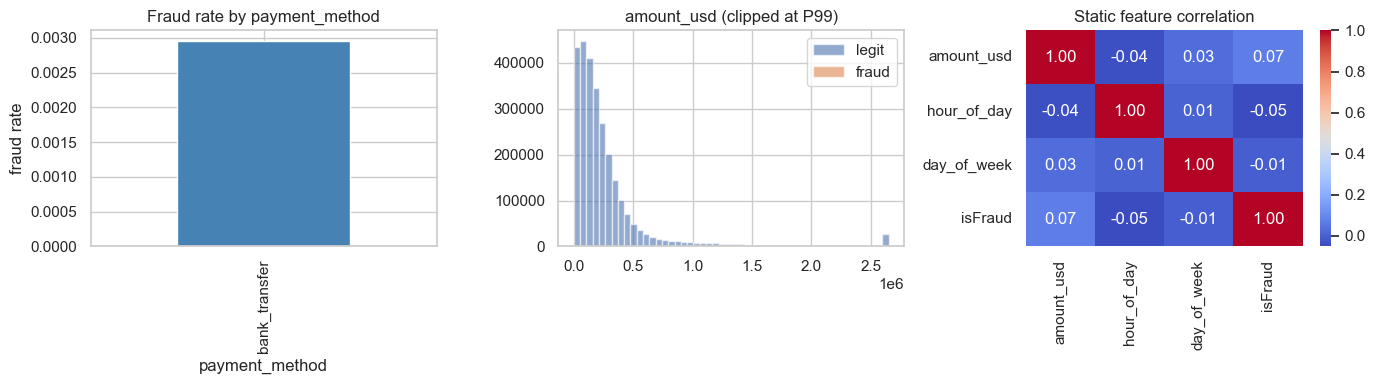

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

fraud_by_pm = df.groupby("payment_method")["isFraud"].mean().sort_values(ascending=False)
fraud_by_pm.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Fraud rate by payment_method")
axes[0].set_ylabel("fraud rate")

df.loc[df["isFraud"] == 0, "amount_usd"].clip(upper=df["amount_usd"].quantile(0.99)).hist(
    bins=50, alpha=0.6, label="legit", ax=axes[1]
)
df.loc[df["isFraud"] == 1, "amount_usd"].clip(upper=df["amount_usd"].quantile(0.99)).hist(
    bins=50, alpha=0.6, label="fraud", ax=axes[1]
)
axes[1].set_title("amount_usd (clipped at P99)")
axes[1].legend()

corr_cols = ["amount_usd", "hour_of_day", "day_of_week", "isFraud"]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[2])
axes[2].set_title("Static feature correlation")
plt.tight_layout()
plt.show()

In [7]:
train, val, test = time_split(df)
for name, part in [("train", train), ("val", val), ("test", test)]:
    print(
        f"{name}: n={len(part):,} fraud_rate={part['isFraud'].mean():.4%} "
        f"frauds={part['isFraud'].sum():,}"
    )
drift_ratio = test["isFraud"].mean() / max(train["isFraud"].mean(), 1e-9)
print(
    f"\nPrior shift (test/train fraud rate): {drift_ratio:.1f}x — "
    f"inferred target rate for training: {infer_target_fraud_rate(val, test):.4%}",
    flush=True,
)
assert test["isFraud"].sum() >= 50, "Test split needs >= 50 fraud rows"

train: n=2,652,409 fraud_rate=0.2173% frauds=5,763
val: n=80,000 fraud_rate=1.4712% frauds=1,177
test: n=37,984 fraud_rate=3.3093% frauds=1,257

Prior shift (test/train fraud rate): 15.2x — inferred target rate for training: 2.3903%


In [8]:
import time

train_fit, target_rate, train_meta = prepare_training_frame(
    train,
    val,
    test,
    max_train_rows=MAX_TRAIN_ROWS,
    imbalance_strategy=IMBALANCE_STRATEGY,
    target_fraud_rate=TARGET_FRAUD_RATE,
)
print(
    f"Training on target fraud rate {target_rate:.4%} ({train_meta['target_fraud_rate_source']})",
    flush=True,
)

x_train, y_train = prepare_xy(train_fit, columns=FEATURE_COLUMNS)
x_val, y_val = prepare_xy(val, columns=FEATURE_COLUMNS)
x_test, y_test = prepare_xy(test, columns=FEATURE_COLUMNS)

train_meta["fraud_types_only"] = FRAUD_TYPES_ONLY
train_meta["fraud_relevant_types"] = ["CASH_OUT", "TRANSFER"]

pos_weight, weight_source = resolve_scale_pos_weight(
    imbalance_strategy=IMBALANCE_STRATEGY,
    y_train=y_train,
    target_fraud_rate=target_rate,
    multiplier=FRAUD_WEIGHT_MULTIPLIER,
)
train_meta["scale_pos_weight"] = pos_weight
train_meta["scale_pos_weight_source"] = weight_source
print(
    f"Train fit: {y_train.sum():,} fraud / {len(y_train):,} "
    f"({y_train.mean():.4%}) — scale_pos_weight={pos_weight:,.1f} ({weight_source})",
    flush=True,
)

classifier_params = {}
if TUNE_HYPERPARAMS:
    print("\n=== Hyperparameter search ===", flush=True)
    classifier_params, cv_score = tune_classifier(
        x_train,
        y_train,
        n_iter=TUNE_N_ITER,
        sample_frac=TUNE_SAMPLE_FRAC,
        scale_pos_weight=pos_weight,
        use_gpu=USE_GPU,
        verbose=2,
    )
    print(f"Best CV PR-AUC={cv_score:.4f}", flush=True)
    print("Best params:", classifier_params, flush=True)

device = resolve_xgb_device(USE_GPU)
clf = build_classifier(
    FEATURE_COLUMNS,
    scale_pos_weight=pos_weight,
    use_gpu=USE_GPU,
    callbacks=training_progress_callbacks(period=TRAIN_LOG_EVERY),
    **classifier_params,
)
print(f"\n=== Final training (device={device}) ===", flush=True)
print(
    f"Rows: train={len(x_train):,} val={len(x_val):,} | "
    f"Logging val aucpr every {TRAIN_LOG_EVERY} rounds (below)",
    flush=True,
)

pipeline = Pipeline([("clf", clf)])
t0 = time.perf_counter()
pipeline.fit(
    x_train,
    y_train,
    clf__eval_set=[(x_val, y_val)],
    clf__verbose=False,
)
elapsed = time.perf_counter() - t0
fitted = pipeline.named_steps["clf"]
best_iter = getattr(fitted, "best_iteration", None)
best_score = getattr(fitted, "best_score", None)
print(f"\nTraining complete in {elapsed:.1f}s", flush=True)
if best_iter is not None:
    print(f"Early stop at round {best_iter} (best val score: {best_score})", flush=True)

Recency window: 2,652,409 -> 2,000,000 train rows (frauds kept 5,763/5,763, fraud_rate 0.2173% -> 0.2882%)
Undersampled train: 2,000,000 -> 241,102 rows (frauds=5,763, fraud_rate=2.3903%, target=2.39%)
Training on target fraud rate 2.3903% (inferred_val_test)
Train fit: 5,763 fraud / 241,102 (2.3903%) — scale_pos_weight=1.0 (undersample_balanced)

=== Hyperparameter search ===
XGBoost GPU (CUDA) available — training on GPU.
Hyperparameter search: 8 candidates × 3-fold CV (24 fits, 60,275 rows)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


d:\Documents\Portofolio Projects\real-time-fraud-detection\.venv-analysis\Lib\site-packages\xgboost\core.py:751: UserWarning: [15:48:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END learning_rate=0.05, max_depth=5, min_child_weight=1, subsample=0.8; total time=   0.6s
[CV] END learning_rate=0.05, max_depth=5, min_child_weight=1, subsample=0.8; total time=   0.5s
[CV] END learning_rate=0.05, max_depth=5, min_child_weight=1, subsample=0.8; total time=   0.6s
[CV] END learning_rate=0.1, max_depth=4, min_child_weight=1, subsample=0.8; total time=   0.4s
[CV] END learning_rate=0.1, max_depth=4, min_child_weight=1, subsample=0.8; total time=   0.4s
[CV] END learning_rate=0.1, max_depth=4, min_child_weight=1, subsample=0.8; total time=   0.4s
[CV] END learning_rate=0.05, max_depth=3, min_child_weight=1, subsample=0.8; total time=   0.3s
[CV] END learning_rate=0.05, max_depth=3, min_child_weight=1, subsample=0.8; total time=   0.3s
[CV] END learning_rate=0.05, max_depth=3, min_child_weight=1, subsample=0.8; total time=   0.3s
[CV] END learning_rate=0.1, max_depth=4, min_child_weight=5, subsample=0.8; total time=   0.4s
[CV] END learning_rate=0.1, max_depth=4, min


--- Operating point comparison (validation) ---
  recall mode target:    recall>=70%  -> t=0.2499
  precision mode target: precision>=70% -> t=0.7408

Threshold trade-off (validation, n=80,000, frauds=1,177):
 threshold recall precision    f1  fraud_caught  missed_fraud  false_alarms   fpr    fnr
      0.25 70.77%    10.50% 0.183           833           344          7097 9.00% 29.23%
      0.25 70.77%    10.56% 0.184           833           344          7055 8.95% 29.23%
      0.30 60.41%    17.71% 0.274           711           466          3304 4.19% 39.59%
      0.65 33.90%    49.88% 0.404           399           778           401 0.51% 66.10%
      0.74 27.02%    70.51% 0.391           318           859           133 0.17% 72.98%

Deployed threshold (recall): 0.2499 [max_precision_at_recall>=0.7] val precision=0.1056 recall=0.7077

  Validation @ threshold = 0.2499

Confusion matrix (rows=actual, cols=predicted):
                 pred_legit  pred_fraud
  actual legit       71,768  

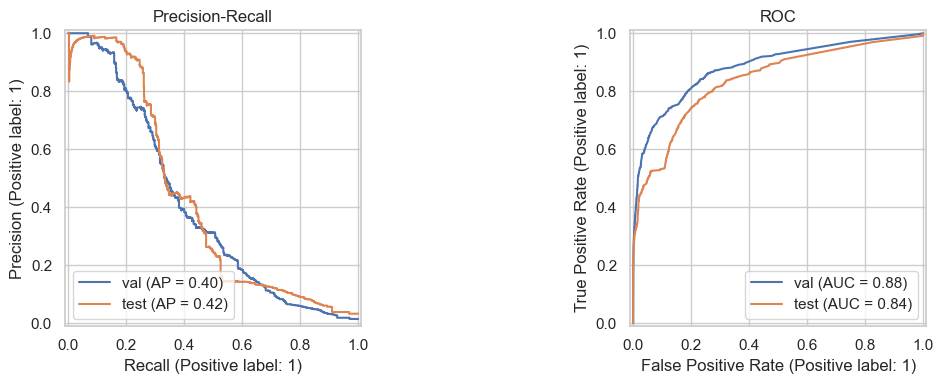

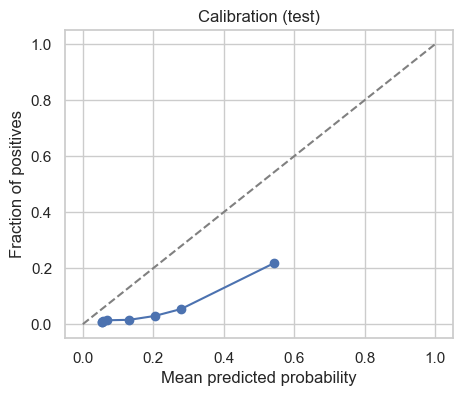

In [9]:
val_prob = pipeline.predict_proba(x_val)[:, 1]
test_prob = pipeline.predict_proba(x_test)[:, 1]
y_val_arr = y_val.to_numpy()

# Compare recall-heavy vs precision-heavy vs high cutoffs before picking production threshold
compare_operating_points(
    y_val_arr,
    val_prob,
    min_precision=MIN_PRECISION_TARGET,
    min_recall=MIN_RECALL_TARGET,
    manual_threshold=MANUAL_THRESHOLD,
)

best_threshold, threshold_strategy, meta = resolve_operating_threshold(
    y_val_arr,
    val_prob,
    mode=THRESHOLD_MODE,
    min_precision=MIN_PRECISION_TARGET,
    min_recall=MIN_RECALL_TARGET,
    manual_threshold=MANUAL_THRESHOLD,
)
val_p, val_r = meta["val_precision"], meta["val_recall"]
print(
    f"\nDeployed threshold ({THRESHOLD_MODE}): {best_threshold:.4f} "
    f"[{threshold_strategy}] val precision={val_p:.4f} recall={val_r:.4f}",
    flush=True,
)

val_metrics = print_evaluation_report("Validation", y_val, val_prob, best_threshold)
test_metrics = print_evaluation_report("Test", y_test, test_prob, best_threshold)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PrecisionRecallDisplay.from_predictions(y_val, val_prob, ax=axes[0], name="val")
PrecisionRecallDisplay.from_predictions(y_test, test_prob, ax=axes[0], name="test")
axes[0].set_title("Precision-Recall")
RocCurveDisplay.from_predictions(y_val, val_prob, ax=axes[1], name="val")
RocCurveDisplay.from_predictions(y_test, test_prob, ax=axes[1], name="test")
axes[1].set_title("ROC")
plt.tight_layout()
plt.show()

prob_true, prob_pred = calibration_curve(y_test, test_prob, n_bins=10, strategy="quantile")
plt.figure(figsize=(5, 4))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration (test)")
plt.show()

In [10]:
bundle = save_model_bundle(
    pipeline,
    MODEL_PATH,
    feature_columns=FEATURE_COLUMNS,
    numeric_columns=NUMERIC_FEATURES,
    categorical_columns=CATEGORICAL_FEATURES,
    best_threshold=best_threshold,
    metrics={
        "val": val_metrics,
        "test": test_metrics,
        "threshold_strategy": threshold_strategy,
        "threshold_mode": THRESHOLD_MODE,
        "min_recall_target": MIN_RECALL_TARGET,
        "min_precision_target": MIN_PRECISION_TARGET,
        "val_precision_at_threshold": val_p,
        "val_recall_at_threshold": val_r,
    },
    include_history=False,
    classifier_params=classifier_params or None,
    scale_pos_weight=pos_weight,
    fraud_weight_multiplier=FRAUD_WEIGHT_MULTIPLIER,
    device=device,
    training_config=train_meta,
    paysim_csv_sha256=file_sha256(DATA_PATH),
    training_rows=len(train_fit),
)
print("Model SHA256:", file_sha256(MODEL_PATH))
bundle["metrics"]["test"]

Model saved to D:\Documents\Portofolio Projects\real-time-fraud-detection\models\fraud_classifier_v1.joblib
Model SHA256: 44ae0a7515814b6a2407590db8938af4d56699880989f23a2157f35117dbe809


{'threshold': 0.249915212392807,
 'pr_auc': 0.4176487503893693,
 'roc_auc': 0.8392312874461136,
 'precision': 0.14024498491034973,
 'recall': 0.6284805091487669,
 'f1': 0.22931785195936139,
 'precision_at_1pct': 0.862796833773087,
 'specificity': 0.8681351594195006,
 'false_positive_rate': 0.13186484058049935,
 'false_negative_rate': 0.3715194908512331,
 'true_positives': 790,
 'false_positives': 4843,
 'true_negatives': 31884,
 'false_negatives': 467,
 'fraud_caught_pct': 0.6284805091487669,
 'fraud_missed_pct': 0.3715194908512331,
 'confusion_matrix': [[31884, 4843], [467, 790]],
 'confusion_matrix_labels': {'rows': ['legit', 'fraud'],
  'cols': ['pred_legit', 'pred_fraud']}}

## Integration notes (follow-up)

**v1 (this notebook):** TRANSFER + CASH_OUT scope — features derivable from `TransactionEvent` (no Postgres history).

- `amount_usd`, `hour_of_day`, `day_of_week`, `step`, `is_cash_out`
- `merchant_category_encoded`, `payment_method`, `currency`, `country`
- At scoring time: `step` = hours since PaySim epoch; `is_cash_out` = 1 when `merchant_category == "6011"` (see `step_from_timestamp`, `is_cash_out_from_merchant_category` in `analysis/paysim_training.py`)
- `history_features_required`: `[]`
- `model_type`: `xgboost_classifier`

**v2 (later):** retrain with `include_history=True` and causal user-history features from `sink.load_user_stats` / `load_user_amount_stats`.

**Consumer changes (next step):**

1. Load `fraud_classifier_v1.joblib`.
2. Build one row matching `bundle["feature_columns"]` (pandas `category` dtype for categoricals).
3. Score with `bundle["model"].predict_proba(X)[:, 1] * 100`.
4. Apply `bundle["best_threshold"]` for hard fraud flags. Threshold is set on **validation** using `THRESHOLD_MODE`:
   - `precision` (default): fewer false alarms — raise `MIN_PRECISION_TARGET` (e.g. 0.70)
   - `recall`: catch more fraud (your previous ~69% recall / 12.7% precision profile)
   - `manual`: set `MANUAL_THRESHOLD` (e.g. `0.85`) to slide cutoff up directly

Run the evaluation cell trade-off table before exporting to compare operating points.

Existing `anomaly_v1.joblib` (IsolationForest) stays until you switch the consumer.